In [1]:
import shap
import matplotlib
import pickle
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [2]:
data = pd.read_csv('data/adult.csv', header=None)
data.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
data = data[['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']]
data = data.replace('.*\\?.*', np.nan, regex=True).dropna()
data = pd.get_dummies(data, columns=['workclass', 'marital-status', 'occupation'])

X = data.drop(['income'], axis=1)
y = data['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=21)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [3]:
with open("models/mlp.pkl", "rb") as file:
    model = pickle.load(file)

In [4]:
y_prob = model.predict_proba(X_test_scaled)[:, 1] 
y_pred = np.where(y_prob >= 0.3, " >50K", " <=50K")

In [5]:
perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=3, random_state=21, n_jobs=-1)
imp_perm = pd.Series(perm.importances_mean, index=X.columns)
imp_perm.sort_values(ascending=False).head()

capital-gain                          0.036906
education-num                         0.027951
age                                   0.014917
marital-status_ Married-civ-spouse    0.014651
marital-status_ Never-married         0.010596
dtype: float64

Overall, the most important features globally appear to be capital-gain, education-num, age, and variations of marital status.

In [6]:
explainer = shap.Explainer(model.predict_proba, shap.maskers.Independent(X_train_scaled, max_samples=32223), seed=21)
sv = explainer(X_test_scaled.loc[[40397]])

PermutationExplainer explainer: 2it [00:23, 23.48s/it]               


In [7]:
sv = sv[:, :, 1]
sv.data = X_test.loc[[40397]].values

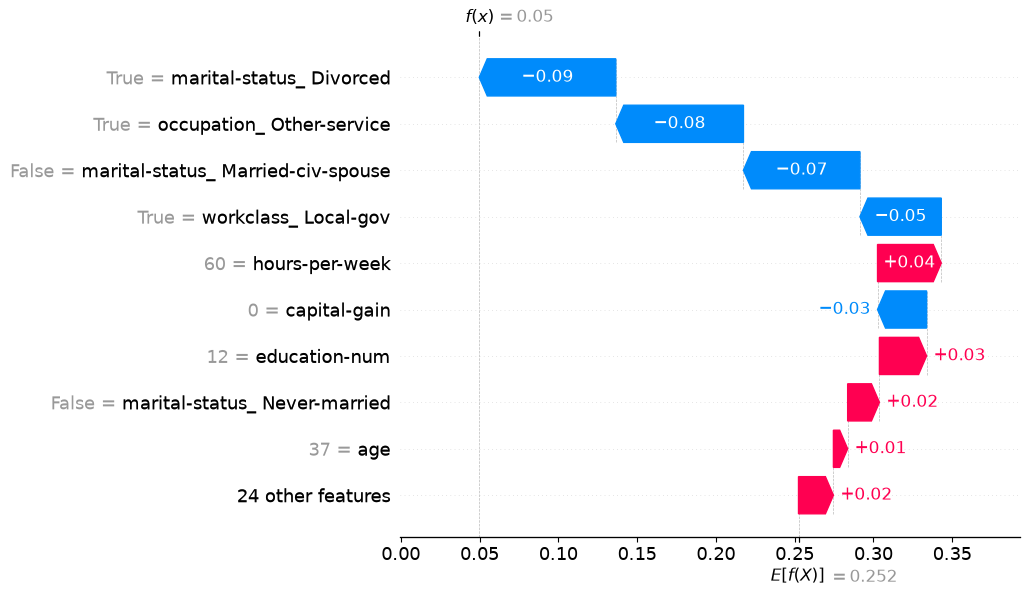

age                                         37
education-num                               12
hours-per-week                              60
capital-gain                                 0
capital-loss                                 0
workclass_ Federal-gov                   False
workclass_ Local-gov                      True
workclass_ Private                       False
workclass_ Self-emp-inc                  False
workclass_ Self-emp-not-inc              False
workclass_ State-gov                     False
workclass_ Without-pay                   False
marital-status_ Divorced                  True
marital-status_ Married-AF-spouse        False
marital-status_ Married-civ-spouse       False
marital-status_ Married-spouse-absent    False
marital-status_ Never-married            False
marital-status_ Separated                False
marital-status_ Widowed                  False
occupation_ Adm-clerical                 False
occupation_ Armed-Forces                 False
occupation_ C

In [8]:
shap.plots.waterfall(sv[0])
print(X_test.loc[40397])
print(y_test.loc[40397])

In this case, the model incorrectly predicted the person to have an income <=50K if using a threshold of 0.3, when they actually had an income >50K. Being divorced, working in a service occupation, and not getting remarried had the biggest impact on the predicted income, even though other features like hours_per_week, education_num, and age were pulling it up.